In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))
import SysSimX

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))
from fem_pendulum import FEMPendulum
import pendulum_config as config

-------------------------------

**Instantiate and Configure FEM Pendulum**

In [2]:
model = FEMPendulum(name="PendulumWithContact", group="Plant")

In [3]:
geom_params = config.GeometryParameters()
print(geom_params)

Pendulum Geometry:
  Rod Radius:    0.05
  Hole Radius:   0.1
  Head Radius:   0.2
  Center Length: 0.8
Wall Geometry:
  Wall Angle:    0.0
  Wall Length X: 0.05
  Wall Length Y: 0.5
  Wall Length Z: 0.1


In [17]:
mat_params = config.MaterialParameters(E_pendulum=2.0e11)
print(mat_params)

Material Parameters Pendulum:
  Young's Modulus: 200000000000.0
  Poisson's Ratio: 0.2
  Density:         7850
Material Parameters Wall:
  Young's Modulus: 210000000000.0
  Poisson's Ratio: 0.2
  Density:         7850
General Thickness: 0.1


In [18]:
mesh_params = config.MeshParameters()
print(mesh_params)

Mesh Parameters:
  Max Element Size: 0.03
  Mesh Order:       2
  Curved Elements:  True
  Refinement Levels:0


In [19]:
init_params = config.InitialConditionParameters()
init_params.angular_position_deg = 0
init_params.drive_torque = 40.0  # Nm
print(init_params)

Initial Conditions:
  Angular Position:     0 deg
  Angular Velocity:     0 rad/s
  Drive Torque:         40.0 Nm


In [20]:
sim_params = config.SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 5.0
sim_params.with_contact = False
sim_params.use_gravity = False
print(sim_params)

Simulation Parameters:
  Simulation Start Time: 0.0 s
  Internal Time Step:    0.01 s
  Simulation End Time:   5.0 s
  Max Solver Error:      1e-06
  Max Solver Iterations: 20
  Use Gravity:           False
  With Contact:          False
  Torque Traction Dist.: linear


In [21]:
contact_params = config.ContactParameters()
contact_params.kn = 1e10
print(contact_params)

Contact Parameters:
   Contact Stiffness: 1.00e+10 N/m


In [22]:
anim_params = config.AnimationParameters()
anim_params.animate = True
print(anim_params)

Animation Parameters:
  Animate:        True
  Interval:       10
  Speed:          50x


In [23]:
model.set_parameters(geom_params=geom_params,
                     mat_params=mat_params,
                     mesh_params=mesh_params,
                     init_params=init_params,
                     sim_params=sim_params,
                     contact_params=contact_params,
                     anim_params=anim_params)

In [13]:
json_dict = {}
for key in model.parameters:
    parm_dict = config.to_json_serializable(model.parameters[key])
    json_dict[key] = parm_dict
    
json_dict_filename = "fem_pendulum_parameters.json"
with open(json_dict_filename, 'w') as json_file:
    import json
    json.dump(json_dict, json_file, indent=4)

In [24]:
model.initialize(0.0)
model.setup_monitoring()
model.display_monitoring()
model.initialize_scene()

HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [25]:
# Analytical solution
I = model.inertia
m = model.mass
q0 = np.deg2rad(model.init_params.angular_position_deg)
omega0 = model.init_params.angular_velocity

# q(t+1) = q(t) + omega(t)*dt + 0.5*alpha(t)*dt^2

def analytic_step(dt, q, omega, torque, I):
    alpha = torque / I
    q_next = q + omega * dt + 0.5 * alpha * dt**2
    omega_next = omega + alpha * dt
    return q_next, omega_next, alpha

def determine_torque(t, t_end, torque=1.0):
    interval = t_end / 6 
    if t < interval:
        return t * torque
    elif t < 2 * interval:
        return interval * torque
    elif t < 3 * interval:
        return interval * torque - (t - 2 * interval) * torque
    elif t < 4 * interval:
        return -(t - 3 * interval) * torque
    elif t < 5 * interval:
        return -(interval) * torque
    else:
        return -interval * torque + (t - 5 * interval) * torque

In [26]:
t = 0.0
dt = 0.01
t_end = model.sim_params.t_end

t_vals = [t]
q_vals = [q0]
a_vals = [omega0]
w_vals = [0.0]

q_an_vals = [q0]
w_an_vals = [omega0]
alpha_an_vals = [0.0]

torque_val = model.init_params.drive_torque
q_an = q0
omega_an = omega0

while t < t_end:
    # Determine torque at current time
    torque = determine_torque(t, t_end, torque=torque_val)
    
    # Compute analytical solution
    q_an, omega_an, alpha_an = analytic_step(dt, q_an, omega_an, torque, I)
    
    # Perform simulation step
    model.set_inputs({'torque':torque}, t)
    model.do_step(t, dt)
    t_next = t + dt

    a_vals.append(model.outputs['alpha'].get())
    w_vals.append(model.outputs['omega'].get())
    q_vals.append(model.outputs['q'].get())

    q_an_vals.append(q_an)
    w_an_vals.append(omega_an)
    alpha_an_vals.append(alpha_an)

    t_vals.append(t_next)
    t = t_next

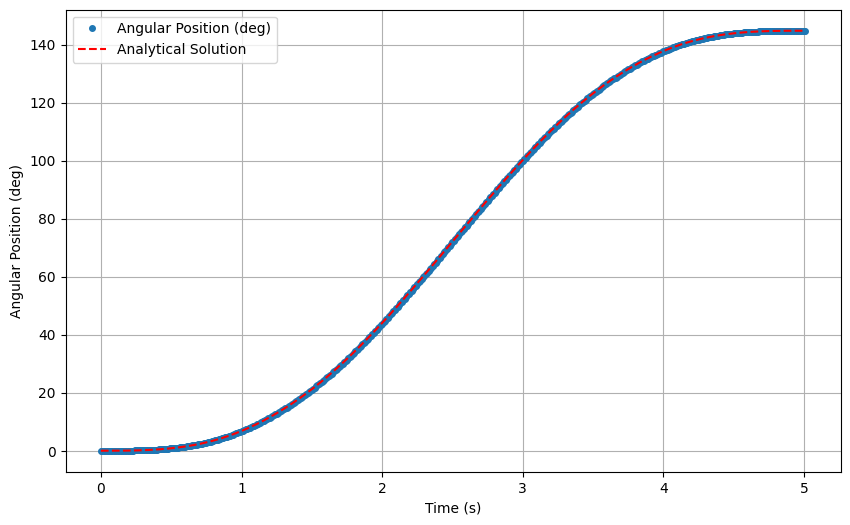

Final Angle (deg): 144.80983728775826 deg


In [27]:
marker_size = 4
fem_style = {'color': 'C0', 'linestyle': 'None', 'marker': 'o', 'markersize': marker_size}

plt.figure(figsize=(10, 6))
plt.plot(t_vals, np.rad2deg(q_vals), label='Angular Position (deg)', **fem_style)
plt.plot(t_vals, np.rad2deg(q_an_vals), label='Analytical Solution', linestyle='--', color='r')
plt.xlabel('Time (s)')
plt.ylabel('Angular Position (deg)')
plt.grid()
plt.legend()
plt.show()

print(f"Final Angle (deg): {np.rad2deg(model.outputs['q'].get())}")

---------------------